# Self-consistent priors in log-posterior space

This notebook implements the particle approximation to the self-consistency map for noisy inference in projected log-belief space. The belief vectors are always stored as 3D zero-mean vectors in the hyperplane `H = {l : sum_i l_i = 0}`. A symmetric 2D frame is used only for plotting.

## Mathematical object being simulated

For a prior distribution `p` over projected log-beliefs, the denoiser is

$$
F_p(y) = \frac{\int_H \ell\, N(y; \ell, \Sigma) p(d\ell)}{\int_H N(y; \ell, \Sigma) p(d\ell)}.
$$

The update rule is

$$
\hat L_t = F_p\left(\hat L_{t-1} + \delta_{x_t} + \varepsilon_t\right),
\qquad \varepsilon_t \sim N(0, \Sigma).
$$

The self-consistent object is represented as three state-conditioned particle distributions `p_s`. Their equal mixture is the marginal prior

$$
p = \frac13\sum_s p_s,
$$

and this marginal prior is what defines the denoiser `F_p`. One iteration maps each conditional cloud `p_s` to the distribution of `hat L_T | S=s`, then rebuilds the marginal from the three updated clouds.

## Parameters

Edit this cell first. The defaults are deliberately modest so the notebook runs quickly; increase `M_TOTAL_PARTICLES`, `N_TOTAL_SAMPLES_PER_ITER`, and `N_ITERATIONS` for smoother fixed-point clouds.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

# States and signals.
STATES = ['Healthy', 'Sickness 1', 'Sickness 2']
SIGNALS = ['Whistle', 'Cough', 'Scratch']

# Likelihood structure. Rows are signals, columns are states.
p_sick_marker = 0.60 #0.40         # P(Cough | Sickness 1), P(Scratch | Sickness 2)
p_sick_cross = .20 #1 / 3         # P(Scratch | Sickness 1), P(Cough | Sickness 2)
p_healthy_nonwhistle = 0.15  # P(Cough | Healthy), P(Scratch | Healthy)

USE_CUSTOM_LIKELIHOOD = False
CUSTOM_L = np.array([
    [0.70, 0.2667, 0.2667],  # Whistle
    [0.15, 0.4000, 0.3333],  # Cough
    [0.15, 0.3333, 0.4000],  # Scratch
])

# Particle fixed-point iteration.
RANDOM_SEED = 15
M_TOTAL_PARTICLES = 999 #600          # total particles in the marginal prior p = (p_1+p_2+p_3)/3
N_TOTAL_SAMPLES_PER_ITER = 999 #600   # total samples generated from the self-consistency map per iteration
M_PARTICLES_PER_STATE = M_TOTAL_PARTICLES // 3
N_SAMPLES_PER_STATE_PER_ITER = N_TOTAL_SAMPLES_PER_ITER // 3
N_ITERATIONS = 600
SNAPSHOT_ITERATIONS = [0, 1, 2, 5, 10, 20, 50, 100, 200, 400, 600]
SIMPLEX_SNAPSHOT = 'last'  # 'last' for final particles, or an iteration saved in SNAPSHOT_ITERATIONS
MIXING_RATE = 0.25         # fraction of particles replaced by new mapped samples each iteration
JITTER_SIGMA = 0.1       # small projected jitter to avoid particle collapse

# Noisy signal model. This is isotropic on H, i.e. Sigma = OBS_NOISE_SIGMA**2 * Pi.
OBS_NOISE_SIGMA = 0.15

# Age distribution q_t. Geometric means q_t = (1 - AGE_LAMBDA) AGE_LAMBDA**(t - 1).
AGE_MODEL = 'geometric'    # 'geometric' or 'fixed'
AGE_LAMBDA = 0.90          # larger means older beliefs on average
FIXED_AGE = 25
MAX_AGE = 80              # numerical truncation for very long geometric tails

# Initial prior. A point mass at the origin is a trivial fixed point, so use a broad start.
INITIAL_PRIOR = 'wide_normal'  # 'wide_normal', 'small_normal', or 'delta_origin'
INITIAL_SCALE = 2.0 #2.0

# Denoiser memory/speed knob. Increase if your machine is comfortable with larger arrays.
DENOISER_CHUNK_SIZE = 256
DENOISER_FIELD_RADIUS_MODE = 'prior_quantile'  # 'prior_quantile' or 'global_plot'
DENOISER_FIELD_PRIOR_QUANTILE = 0.98
DENOISER_FIELD_RADIUS_MULTIPLIER = 1.20
DENOISER_FIELD_MIN_RADIUS = 0.25
PRINT_PROGRESS = True


## Geometry and likelihood objects

In [2]:
one = np.ones(3)
Pi = np.eye(3) - np.outer(one, one) / 3

def project(v):
    """Orthogonally project 3D vectors onto the zero-mean hyperplane H."""
    v = np.asarray(v, dtype=float)
    return v - v.mean(axis=-1, keepdims=True)

def sample_h_normal(rng, n, sigma):
    """Sample N(0, sigma**2 Pi), i.e. isotropic Gaussian noise on H."""
    return project(rng.normal(0.0, sigma, size=(n, 3)))

if USE_CUSTOM_LIKELIHOOD:
    L = np.asarray(CUSTOM_L, dtype=float)
else:
    L = np.array([
        [1 - 2 * p_healthy_nonwhistle, 1 - p_sick_marker - p_sick_cross, 1 - p_sick_marker - p_sick_cross],
        [p_healthy_nonwhistle, p_sick_marker, p_sick_cross],
        [p_healthy_nonwhistle, p_sick_cross, p_sick_marker],
    ], dtype=float)

assert L.shape == (3, 3), 'L must be 3 x 3 with rows=signals and columns=states.'
assert np.all(L > 0), 'Likelihood entries must be positive because we take logs.'
assert np.allclose(L.sum(axis=0), 1.0), 'Each state column of L must sum to 1.'
assert OBS_NOISE_SIGMA > 0, 'The particle denoiser requires positive observation noise.'
assert 0 <= MIXING_RATE <= 1, 'MIXING_RATE must be between 0 and 1.'
assert M_TOTAL_PARTICLES % 3 == 0, 'M_TOTAL_PARTICLES must be divisible by 3.'
assert N_TOTAL_SAMPLES_PER_ITER % 3 == 0, 'N_TOTAL_SAMPLES_PER_ITER must be divisible by 3.'

# Tilde delta is the raw log-likelihood vector. Delta is projected to H.
delta_tilde = np.log(L)
delta = project(delta_tilde)
Delta = L.T @ delta

def cov_delta_given_state(s):
    centered = delta - Delta[s]
    return centered.T @ (centered * L[:, s:s+1])

Cov_delta = np.stack([cov_delta_given_state(s) for s in range(3)])

print('Projection matrix Pi:')
print(Pi)
print('\nLikelihood matrix L[x, s] = P(x | s):')
print('            ' + '  '.join(f'{state:>10}' for state in STATES))
for signal, row in zip(SIGNALS, L):
    print(f'{signal:>10}  ' + '  '.join(f'{value:10.4f}' for value in row))

print('\nProjected signal displacements delta_x:')
print('            ' + '  '.join(f'{state:>10}' for state in STATES))
for signal, row in zip(SIGNALS, delta):
    print(f'{signal:>10}  ' + '  '.join(f'{value:10.4f}' for value in row))

print('\nExpected projected displacements Delta_s = E[delta_x | s]:')
print('            ' + '  '.join(f'{state:>10}' for state in STATES))
for state, row in zip(STATES, Delta):
    print(f'{state:>10}  ' + '  '.join(f'{value:10.4f}' for value in row))


Projection matrix Pi:
[[ 0.6667 -0.3333 -0.3333]
 [-0.3333  0.6667 -0.3333]
 [-0.3333 -0.3333  0.6667]]

Likelihood matrix L[x, s] = P(x | s):
               Healthy  Sickness 1  Sickness 2
   Whistle      0.7000      0.2000      0.2000
     Cough      0.1500      0.6000      0.2000
   Scratch      0.1500      0.2000      0.6000

Projected signal displacements delta_x:
               Healthy  Sickness 1  Sickness 2
   Whistle      0.8352     -0.4176     -0.4176
     Cough     -0.5580      0.8283     -0.2703
   Scratch     -0.5580     -0.2703      0.8283

Expected projected displacements Delta_s = E[delta_x | s]:
               Healthy  Sickness 1  Sickness 2
   Healthy      0.4172     -0.2086     -0.2086
Sickness 1     -0.2794      0.3594     -0.0800
Sickness 2     -0.2794     -0.0800      0.3594


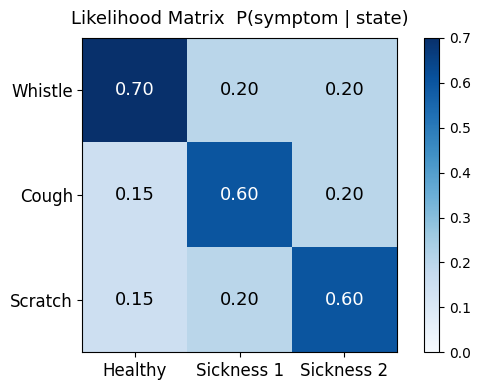

In [3]:
# ── Likelihood heatmap ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(L, vmin=0, vmax=0.7, cmap='Blues')
ax.set_xticks(range(3)); ax.set_xticklabels(STATES, fontsize=12)
ax.set_yticks(range(3)); ax.set_yticklabels(SIGNALS, fontsize=12)
ax.set_title('Likelihood Matrix  P(symptom | state)', fontsize=13, pad=10)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{L[i,j]:.2f}', ha='center', va='center',
                fontsize=13, color='black' if L[i,j] < 0.45 else 'white')
plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.show()

## Particle denoiser

For marginal prior particles `ell_i` pooled from the three state-conditioned clouds, the empirical prior is `p = (1/M) sum_i delta_{ell_i}` and the denoiser is

$$
F_p(y) = \frac{\sum_i \ell_i \exp(-\|y-\ell_i\|^2 / 2\sigma^2)}{\sum_i \exp(-\|y-\ell_i\|^2 / 2\sigma^2)}.
$$

The computation below is chunked over query points so that larger particle counts remain usable.

In [4]:
def particle_denoise(y, particles, sigma=OBS_NOISE_SIGMA, chunk_size=DENOISER_CHUNK_SIZE):
    """Evaluate F_p(y) for one or many projected 3D query vectors."""
    y = project(np.asarray(y, dtype=float))
    single = (y.ndim == 1)
    if single:
        y = y[None, :]

    particles = project(np.asarray(particles, dtype=float))
    out = np.empty_like(y)
    inv_two_var = 0.5 / (sigma * sigma)

    for start in range(0, len(y), chunk_size):
        stop = min(start + chunk_size, len(y))
        chunk = y[start:stop]
        diff = chunk[:, None, :] - particles[None, :, :]
        logw = -inv_two_var * np.sum(diff * diff, axis=-1)
        logw -= logw.max(axis=1, keepdims=True)
        w = np.exp(logw)
        out[start:stop] = (w @ particles) / w.sum(axis=1, keepdims=True)

    return out[0] if single else project(out)

def marginal_particles(state_particles):
    """Return the equal-mixture marginal prior particles from p_s arrays."""
    return project(np.asarray(state_particles, dtype=float).reshape(-1, 3))

def initialize_state_conditioned_priors(rng, m_per_state=M_PARTICLES_PER_STATE):
    """Initialize three conditional priors p_s, stored as shape (3, m_per_state, 3)."""
    total = 3 * m_per_state
    if INITIAL_PRIOR == 'wide_normal':
        particles = sample_h_normal(rng, total, INITIAL_SCALE)
    elif INITIAL_PRIOR == 'small_normal':
        particles = sample_h_normal(rng, total, INITIAL_SCALE * 0.25)
    elif INITIAL_PRIOR == 'delta_origin':
        particles = np.zeros((total, 3))
    else:
        raise ValueError(f'Unknown INITIAL_PRIOR: {INITIAL_PRIOR}')
    return project(particles.reshape(3, m_per_state, 3))


## One application of the self-consistency map

Given current state-conditioned prior particles, this forms the marginal prior used by the denoiser, then separately samples trajectories conditional on each state. The result is a new triple of empirical conditional clouds `tilde p_{n+1,s}`.

In [5]:
def sample_ages(rng, n):
    if AGE_MODEL == 'geometric':
        p_stop = 1.0 - AGE_LAMBDA
        if not (0 < p_stop <= 1):
            raise ValueError('AGE_LAMBDA must be in [0, 1) for a geometric age distribution.')
        ages = rng.geometric(p_stop, size=n)
    elif AGE_MODEL == 'fixed':
        ages = np.full(n, FIXED_AGE, dtype=int)
    else:
        raise ValueError(f'Unknown AGE_MODEL: {AGE_MODEL}')
    return np.minimum(ages, MAX_AGE).astype(int)

def sample_signals_given_states(states, rng):
    probs = L[:, states].T
    cdf = np.cumsum(probs, axis=1)
    u = rng.random(len(states))
    return (u[:, None] > cdf[:, :-1]).sum(axis=1)

def simulate_conditioned_on_state(s, prior_particles, rng, n_samples=N_SAMPLES_PER_STATE_PER_ITER):
    ages = sample_ages(rng, n_samples)
    beliefs = np.zeros((n_samples, 3))
    states = np.full(n_samples, s, dtype=int)

    for k in range(1, int(ages.max()) + 1):
        active = np.flatnonzero(ages >= k)
        if len(active) == 0:
            continue
        x = sample_signals_given_states(states[active], rng)
        eps = sample_h_normal(rng, len(active), OBS_NOISE_SIGMA)
        y = beliefs[active] + delta[x] + eps
        beliefs[active] = particle_denoise(y, prior_particles)

    return project(beliefs), ages

def apply_self_consistency_map(state_particles, rng, n_samples_per_state=N_SAMPLES_PER_STATE_PER_ITER):
    prior_particles = marginal_particles(state_particles)
    mapped_by_state = []
    ages_by_state = []

    for s in range(3):
        mapped_s, ages_s = simulate_conditioned_on_state(s, prior_particles, rng, n_samples_per_state)
        mapped_by_state.append(mapped_s)
        ages_by_state.append(ages_s)

    return project(np.stack(mapped_by_state)), ages_by_state


## Iterate the fixed-point map

The damped update is applied separately to each state-conditioned cloud. The marginal prior used by the denoiser is rebuilt as their equal mixture. The reported gaps are moment-based diagnostics, not proof of convergence.

In [6]:
def cloud_cov(x):
    x = project(x)
    centered = x - x.mean(axis=0, keepdims=True)
    return centered.T @ centered / max(len(x) - 1, 1)

def cloud_trace(x):
    return float(np.trace(cloud_cov(x)))

def moment_gap(a, b):
    mean_gap = np.linalg.norm(a.mean(axis=0) - b.mean(axis=0))
    cov_gap = np.linalg.norm(cloud_cov(a) - cloud_cov(b), ord='fro')
    return float(mean_gap + cov_gap)

def state_moment_gap(old_by_state, mapped_by_state):
    return float(np.mean([moment_gap(old_by_state[s], mapped_by_state[s]) for s in range(3)]))

def conditional_traces(state_particles):
    return np.array([cloud_trace(state_particles[s]) for s in range(3)])

def between_state_trace(state_particles):
    means = np.array([project(state_particles[s]).mean(axis=0) for s in range(3)])
    centered = means - means.mean(axis=0, keepdims=True)
    return float(np.trace(centered.T @ centered / 3))

def damp_particles(old_particles, mapped_particles, rng, m_out=M_PARTICLES_PER_STATE):
    n_new = int(round(MIXING_RATE * m_out))
    n_old = m_out - n_new

    pieces = []
    if n_old > 0:
        old_idx = rng.choice(len(old_particles), size=n_old, replace=True)
        pieces.append(old_particles[old_idx])
    if n_new > 0:
        new_idx = rng.choice(len(mapped_particles), size=n_new, replace=True)
        pieces.append(mapped_particles[new_idx])

    updated = np.vstack(pieces) if pieces else np.empty((0, 3))
    if JITTER_SIGMA > 0:
        updated = updated + sample_h_normal(rng, len(updated), JITTER_SIGMA)
    return project(updated[rng.permutation(len(updated))])

def damp_state_particles(old_by_state, mapped_by_state, rng):
    updated = [damp_particles(old_by_state[s], mapped_by_state[s], rng) for s in range(3)]
    return project(np.stack(updated))

def run_fixed_point_iteration():
    rng = np.random.default_rng(RANDOM_SEED)
    state_particles = initialize_state_conditioned_priors(rng)
    history = []
    last = None
    snapshot_set = {i for i in SNAPSHOT_ITERATIONS if 0 <= i <= N_ITERATIONS}
    snapshots = {0: state_particles.copy()} if 0 in snapshot_set else {}

    for iteration in range(1, N_ITERATIONS + 1):
        old_by_state = state_particles.copy()
        old_marginal = marginal_particles(old_by_state)
        mapped_by_state, ages_by_state = apply_self_consistency_map(old_by_state, rng)
        mapped_marginal = marginal_particles(mapped_by_state)
        state_particles = damp_state_particles(old_by_state, mapped_by_state, rng)
        updated_marginal = marginal_particles(state_particles)
        prior_marginal_trace = cloud_trace(updated_marginal)
        mapped_marginal_trace = cloud_trace(mapped_marginal)
        prior_within_trace = float(np.mean(conditional_traces(state_particles)))
        mapped_within_trace = float(np.mean(conditional_traces(mapped_by_state)))
        ages = np.concatenate(ages_by_state)

        row = {
            'iteration': iteration,
            'gap_marginal_old_to_map': moment_gap(old_marginal, mapped_marginal),
            'gap_marginal_old_to_updated': moment_gap(old_marginal, updated_marginal),
            'gap_state_old_to_map': state_moment_gap(old_by_state, mapped_by_state),
            'gap_state_old_to_updated': state_moment_gap(old_by_state, state_particles),
            'prior_marginal_trace': prior_marginal_trace,
            'mapped_marginal_trace': mapped_marginal_trace,
            'prior_conditional_traces': conditional_traces(state_particles),
            'mapped_conditional_traces': conditional_traces(mapped_by_state),
            'prior_within_trace': prior_within_trace,
            'mapped_within_trace': mapped_within_trace,
            'prior_between_trace': between_state_trace(state_particles),
            'mapped_between_trace': between_state_trace(mapped_by_state),
            'mean_radius': float(np.mean(np.linalg.norm(updated_marginal, axis=1))),
            'mean_age': float(np.mean(ages)),
            'max_age': int(np.max(ages)),
        }
        history.append(row)
        last = {'mapped_by_state': mapped_by_state, 'ages_by_state': ages_by_state}
        if iteration in snapshot_set:
            snapshots[iteration] = state_particles.copy()

        if PRINT_PROGRESS:
            print(
                f"iter {iteration:02d} | gap marginal={row['gap_marginal_old_to_map']:.4f} "
                f"| gap state={row['gap_state_old_to_map']:.4f} "
                f"| trace marginal={row['prior_marginal_trace']:.4f} "
                f"| trace within={row['prior_within_trace']:.4f} "
                f"| trace between={row['prior_between_trace']:.4f} "
                f"| mean age={row['mean_age']:.2f}"
            )

    return state_particles, history, last, snapshots

state_particles, history, last_map, snapshots = run_fixed_point_iteration()
particles = marginal_particles(state_particles)


iter 01 | gap marginal=7.4869 | gap state=4.8186 | trace marginal=9.8307 | trace within=9.3186 | trace between=0.5303 | mean age=10.34
iter 02 | gap marginal=4.9433 | gap state=4.2951 | trace marginal=11.2509 | trace within=9.6221 | trace between=1.6464 | mean age=9.85
iter 03 | gap marginal=4.9935 | gap state=3.8272 | trace marginal=12.7023 | trace within=9.4012 | trace between=3.3166 | mean age=10.13
iter 04 | gap marginal=4.2363 | gap state=3.2650 | trace marginal=13.6880 | trace within=9.0256 | trace between=4.6758 | mean age=10.02
iter 05 | gap marginal=3.5767 | gap state=2.6969 | trace marginal=14.2808 | trace within=8.0908 | trace between=6.2000 | mean age=10.25
iter 06 | gap marginal=3.5820 | gap state=1.7751 | trace marginal=14.5781 | trace within=7.9729 | trace between=6.6146 | mean age=10.22
iter 07 | gap marginal=2.7067 | gap state=1.6318 | trace marginal=15.5813 | trace within=7.6349 | trace between=7.9537 | mean age=9.68
iter 08 | gap marginal=3.7931 | gap state=1.7974 | 

## Diagnostics

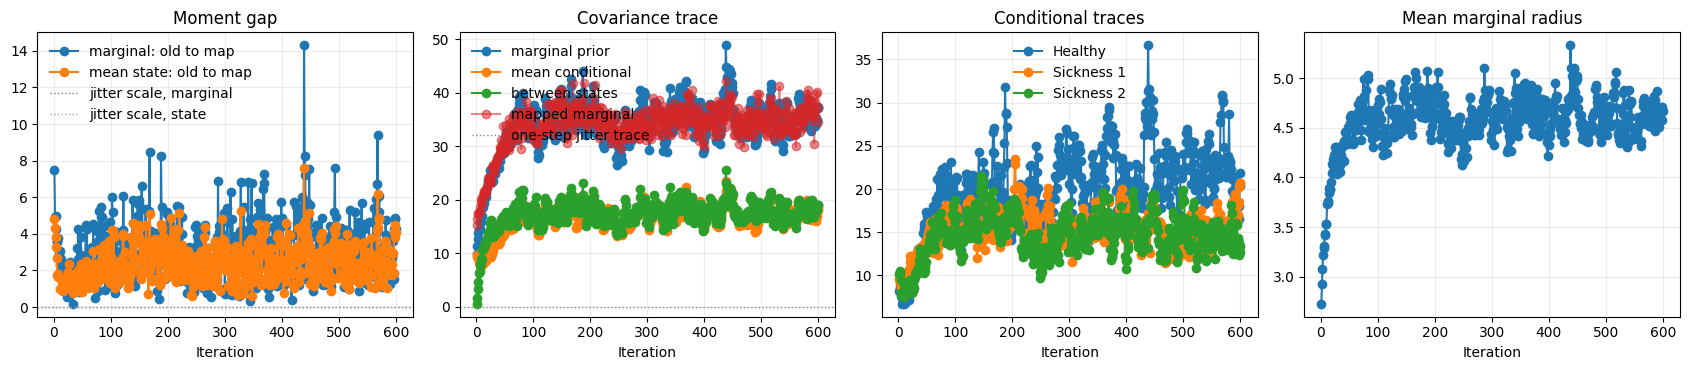

In [7]:
iters = np.array([row['iteration'] for row in history])
gap_marginal_map = np.array([row['gap_marginal_old_to_map'] for row in history])
gap_marginal_updated = np.array([row['gap_marginal_old_to_updated'] for row in history])
gap_state_map = np.array([row['gap_state_old_to_map'] for row in history])
gap_state_updated = np.array([row['gap_state_old_to_updated'] for row in history])
prior_marginal_trace = np.array([row['prior_marginal_trace'] for row in history])
mapped_marginal_trace = np.array([row['mapped_marginal_trace'] for row in history])
prior_within_trace = np.array([row['prior_within_trace'] for row in history])
mapped_within_trace = np.array([row['mapped_within_trace'] for row in history])
prior_between_trace = np.array([row['prior_between_trace'] for row in history])
prior_conditional_traces = np.array([row['prior_conditional_traces'] for row in history])
mean_radius = np.array([row['mean_radius'] for row in history])

# Rough scale induced by one independent projected jitter draw. This is a reference scale,
# not a convergence criterion, because Monte Carlo sampling and the denoiser map also add variability.
jitter_trace_reference = 2 * JITTER_SIGMA**2
jitter_gap_reference_marginal = np.sqrt(2) * JITTER_SIGMA**2 + JITTER_SIGMA * np.sqrt(2 / M_TOTAL_PARTICLES)
jitter_gap_reference_state = np.sqrt(2) * JITTER_SIGMA**2 + JITTER_SIGMA * np.sqrt(2 / M_PARTICLES_PER_STATE)

fig, axes = plt.subplots(1, 4, figsize=(17, 3.8))

axes[0].plot(iters, gap_marginal_map, marker='o', label='marginal: old to map')
axes[0].plot(iters, gap_state_map, marker='o', label='mean state: old to map')
axes[0].axhline(jitter_gap_reference_marginal, color='0.45', lw=1.0, ls=':', label='jitter scale, marginal')
axes[0].axhline(jitter_gap_reference_state, color='0.65', lw=1.0, ls=':', label='jitter scale, state')
axes[0].set_title('Moment gap')
axes[0].set_xlabel('Iteration')
axes[0].legend(frameon=False)

axes[1].plot(iters, prior_marginal_trace, marker='o', label='marginal prior')
axes[1].plot(iters, prior_within_trace, marker='o', label='mean conditional')
axes[1].plot(iters, prior_between_trace, marker='o', label='between states')
axes[1].plot(iters, mapped_marginal_trace, marker='o', alpha=0.55, label='mapped marginal')
axes[1].axhline(jitter_trace_reference, color='0.55', lw=1.0, ls=':', label='one-step jitter trace')
axes[1].set_title('Covariance trace')
axes[1].set_xlabel('Iteration')
axes[1].legend(frameon=False)

for s, state in enumerate(STATES):
    axes[2].plot(iters, prior_conditional_traces[:, s], marker='o', label=state)
axes[2].set_title('Conditional traces')
axes[2].set_xlabel('Iteration')
axes[2].legend(frameon=False)

axes[3].plot(iters, mean_radius, marker='o')
axes[3].set_title('Mean marginal radius')
axes[3].set_xlabel('Iteration')

for ax in axes:
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


## Symmetric 2D display

This display frame is only a plotting device. The simulated particles and updates above remain 3D vectors in `H`.

The panel titled `Mapped conditional clouds before damping` is the freshly generated image of the current prior under the self-consistency map: samples from `tilde p_{n+1,s}` for each true state `s`, before mixing them with old particles. The snapshots below it show the updated state-conditioned prior clouds retained during the iteration, including iteration 0.

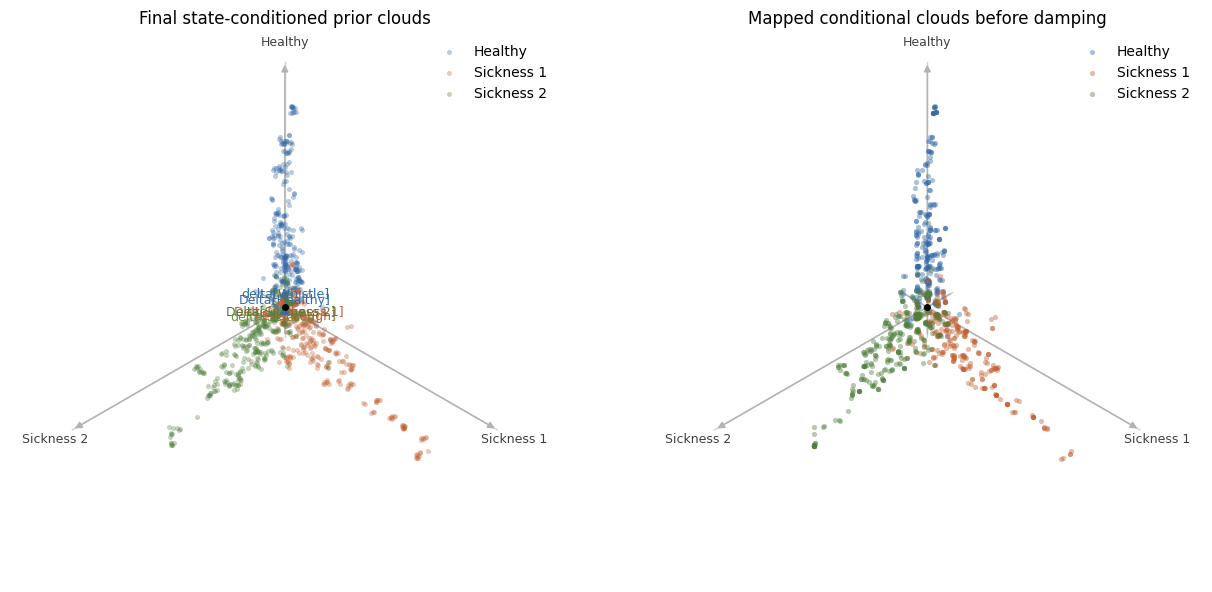

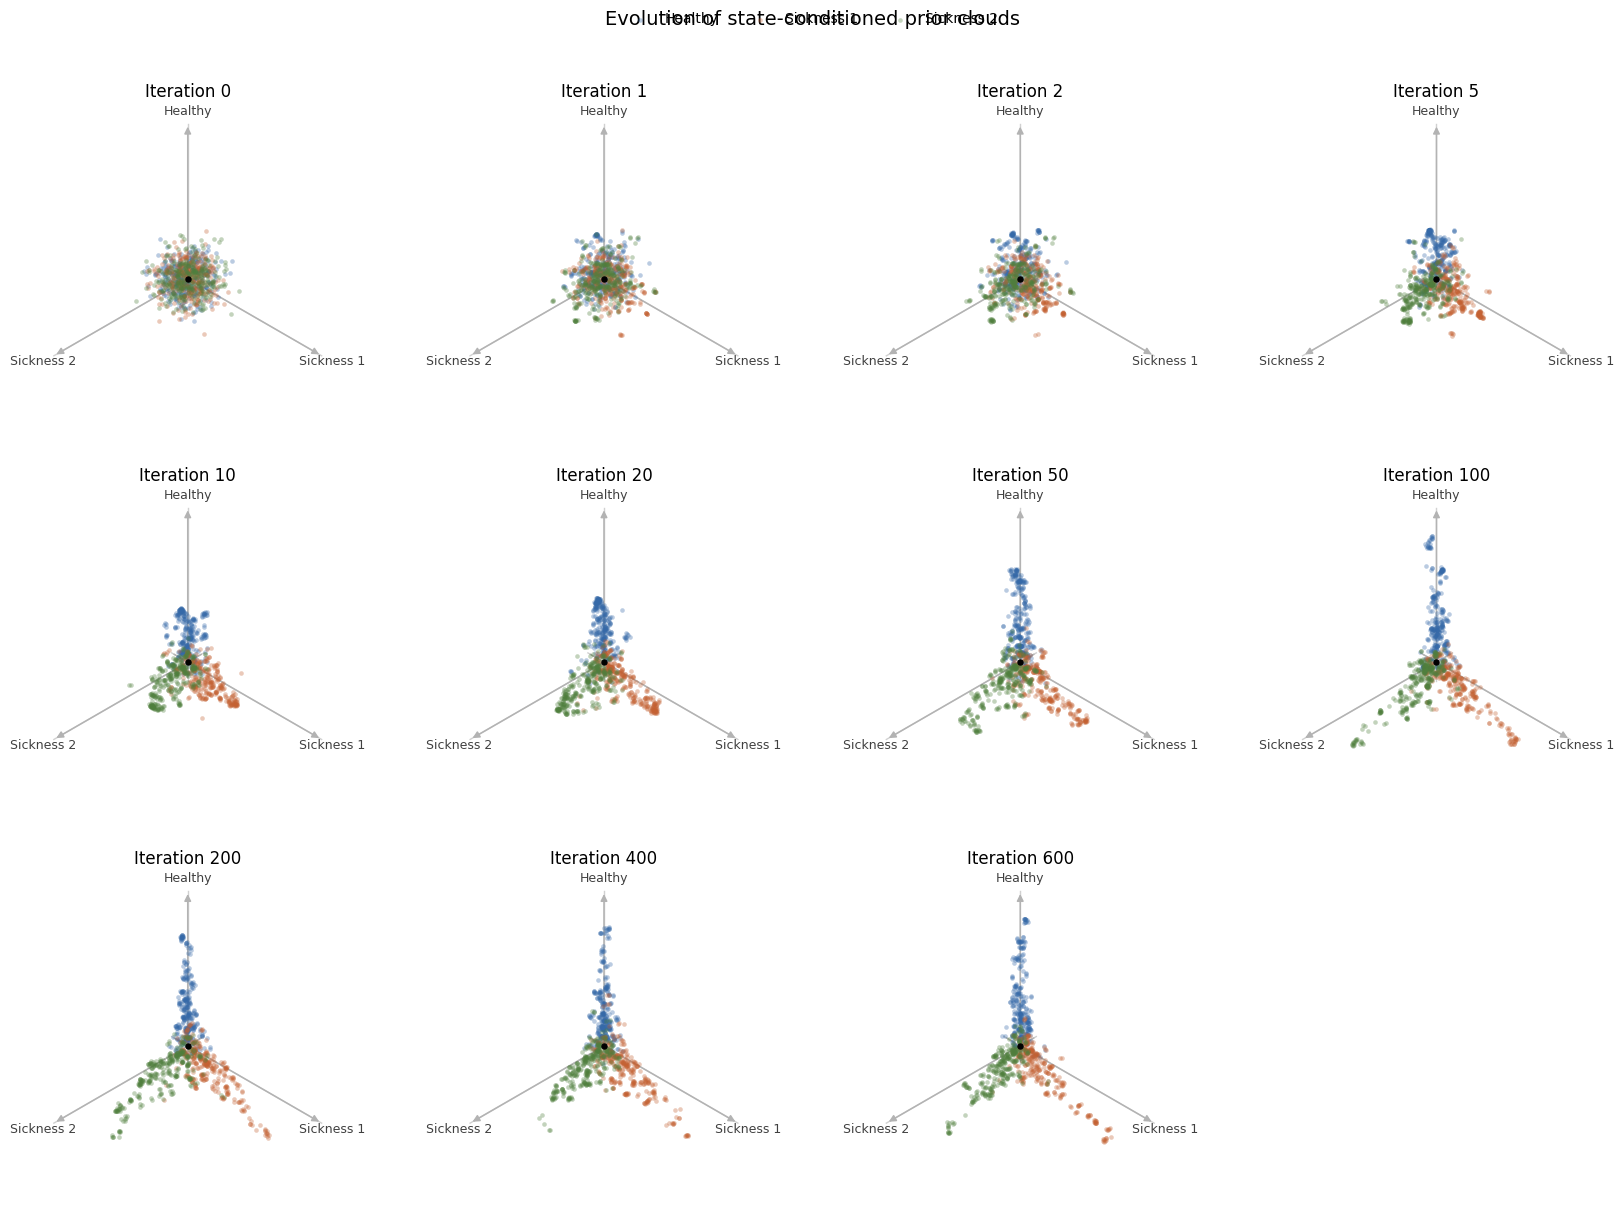

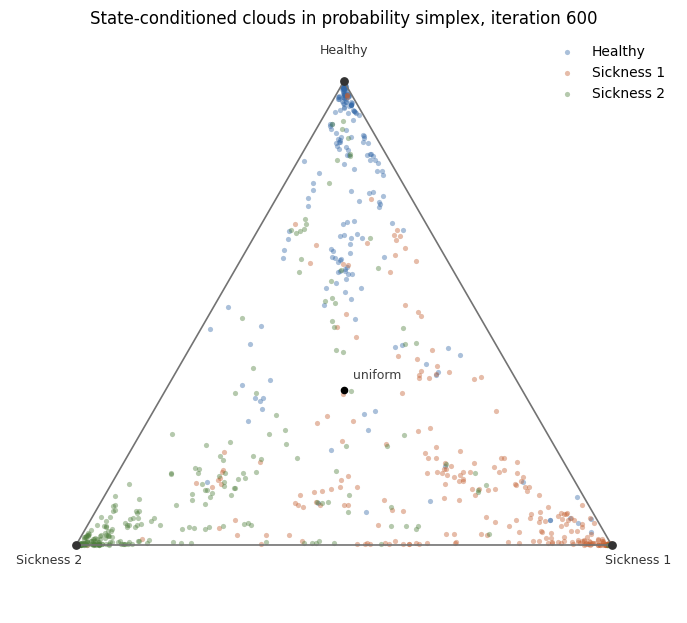

In [8]:
display_frame = np.array([
    [0.0, 1.0],
    [np.sqrt(3) / 2, -0.5],
    [-np.sqrt(3) / 2, -0.5],
])

def to_display(v):
    return project(v) @ display_frame

def draw_state_axes(ax, radius):
    for state, direction in zip(STATES, display_frame):
        start = -0.12 * radius * direction
        end = radius * direction
        ax.plot([start[0], end[0]], [start[1], end[1]], color='0.82', lw=1.0, zorder=0)
        ax.annotate('', xy=end, xytext=start,
                    arrowprops=dict(arrowstyle='-|>', color='0.70', lw=1.1, mutation_scale=10),
                    zorder=1)
        label_pos = 1.08 * radius * direction
        ax.text(label_pos[0], label_pos[1], state, ha='center', va='center', fontsize=9, color='0.25')

def plot_vector(ax, v, label, color, linestyle='-', linewidth=2.2, alpha=1.0):
    xy = to_display(v)
    ax.annotate('', xy=xy, xytext=(0, 0),
                arrowprops=dict(arrowstyle='-|>', color=color, lw=linewidth,
                                linestyle=linestyle, mutation_scale=13, alpha=alpha),
                zorder=5)
    norm = np.linalg.norm(xy)
    offset = np.array([0.02, 0.02]) if norm == 0 else xy / norm * 0.07
    ax.text(*(xy + offset), label, color=color, fontsize=9, ha='center', va='center')

prior_by_state_xy = [to_display(state_particles[s]) for s in range(3)]
mapped_by_state_xy = [to_display(last_map['mapped_by_state'][s]) for s in range(3)]
prior_xy = to_display(marginal_particles(state_particles))
mapped_xy = to_display(marginal_particles(last_map['mapped_by_state']))
all_xy = np.vstack([prior_xy, mapped_xy, to_display(delta), to_display(Delta)])
radius = max(1.0, 1.20 * np.max(np.linalg.norm(all_xy, axis=1)))

state_colors = ['#3569a8', '#c46132', '#4f7f3d']
signal_colors = ['#2f6f9f', '#c65d32', '#6f8f3a']

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

ax = axes[0]
draw_state_axes(ax, radius)
for s, color in enumerate(state_colors):
    xy = prior_by_state_xy[s]
    ax.scatter(xy[:, 0], xy[:, 1], s=13, color=color, alpha=0.34, linewidth=0, label=STATES[s])
for signal, v, color in zip(SIGNALS, delta, signal_colors):
    plot_vector(ax, v, f'delta[{signal}]', color=color)
for state, v, color in zip(STATES, Delta, state_colors):
    plot_vector(ax, v, f'Delta[{state}]', color=color, linestyle='--', linewidth=1.8, alpha=0.82)
ax.scatter([0], [0], s=16, color='black', zorder=6)
ax.set_title('Final state-conditioned prior clouds')
ax.legend(frameon=False, loc='upper right')

ax = axes[1]
draw_state_axes(ax, radius)
for s, color in enumerate(state_colors):
    xy = mapped_by_state_xy[s]
    ax.scatter(xy[:, 0], xy[:, 1], s=14, color=color, alpha=0.42, linewidth=0, label=STATES[s])
ax.scatter([0], [0], s=16, color='black', zorder=6)
ax.set_title('Mapped conditional clouds before damping')
ax.legend(frameon=False, loc='upper right')

for ax in axes:
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-radius * 1.12, radius * 1.12)
    ax.set_ylim(-radius * 1.12, radius * 1.12)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.show()

# Evolution of the state-conditioned prior clouds across selected iterations.
snapshot_items = sorted(snapshots.items())
n_snapshots = len(snapshot_items)
n_cols = min(4, n_snapshots)
n_rows = int(np.ceil(n_snapshots / n_cols))

snapshot_xy = [to_display(clouds.reshape(-1, 3)) for _, clouds in snapshot_items]
snapshot_limit_points = np.vstack(snapshot_xy + [to_display(delta), to_display(Delta)])
snapshot_radius = max(1.0, 1.20 * np.max(np.linalg.norm(snapshot_limit_points, axis=1)))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 4.0 * n_rows), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for ax, (iteration, clouds) in zip(axes.flat, snapshot_items):
    ax.set_visible(True)
    draw_state_axes(ax, snapshot_radius)
    for s, color in enumerate(state_colors):
        xy = to_display(clouds[s])
        ax.scatter(xy[:, 0], xy[:, 1], s=11, color=color, alpha=0.34, linewidth=0, label=STATES[s])
    ax.scatter([0], [0], s=13, color='black', zorder=6)
    ax.set_title(f'Iteration {iteration}')
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-snapshot_radius * 1.12, snapshot_radius * 1.12)
    ax.set_ylim(-snapshot_radius * 1.12, snapshot_radius * 1.12)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, loc='upper center', ncol=3)
fig.suptitle('Evolution of state-conditioned prior clouds', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# Simplex view: convert zero-mean log-beliefs to posterior probabilities.
def logbelief_to_probability(log_beliefs):
    log_beliefs = np.asarray(log_beliefs, dtype=float)
    shifted = log_beliefs - log_beliefs.max(axis=-1, keepdims=True)
    unnormalized = np.exp(shifted)
    return unnormalized / unnormalized.sum(axis=-1, keepdims=True)

def probability_to_simplex_xy(probabilities):
    return np.asarray(probabilities, dtype=float) @ display_frame

def draw_probability_simplex(ax):
    closed = np.vstack([display_frame, display_frame[0]])
    ax.plot(closed[:, 0], closed[:, 1], color='0.45', lw=1.2)
    for state, vertex in zip(STATES, display_frame):
        ax.scatter([vertex[0]], [vertex[1]], s=28, color='0.20', zorder=4)
        ax.text(*(1.10 * vertex), state, ha='center', va='center', fontsize=9, color='0.20')
    ax.scatter([0], [0], s=20, color='black', zorder=4)
    ax.text(0.03, 0.03, 'uniform', fontsize=9, color='0.25', ha='left', va='bottom')

if SIMPLEX_SNAPSHOT == 'last':
    simplex_iteration = N_ITERATIONS
    simplex_clouds = state_particles
else:
    requested_iteration = int(SIMPLEX_SNAPSHOT)
    saved_iterations = np.array(sorted(snapshots))
    simplex_iteration = int(saved_iterations[np.argmin(np.abs(saved_iterations - requested_iteration))])
    simplex_clouds = snapshots[simplex_iteration]

fig, ax = plt.subplots(figsize=(7, 7))
draw_probability_simplex(ax)
for s, color in enumerate(state_colors):
    probabilities = logbelief_to_probability(simplex_clouds[s])
    xy = probability_to_simplex_xy(probabilities)
    ax.scatter(xy[:, 0], xy[:, 1], s=14, color=color, alpha=0.42, linewidth=0, label=STATES[s])
ax.set_title(f'State-conditioned clouds in probability simplex, iteration {simplex_iteration}')
ax.legend(frameon=False, loc='upper right')
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-1.08, 1.08)
ax.set_ylim(-0.72, 1.16)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()


## Posterior denoiser field

This optional cell visualizes the learned denoising map `F_p(y)` on a coarse grid in the plotted plane. The query points are artificial `y` values, not particles. By default the grid radius is chosen from a high quantile of the current marginal prior radius; set `DENOISER_FIELD_RADIUS_MODE = 'global_plot'` to use the broader radius from the previous log-space figure.

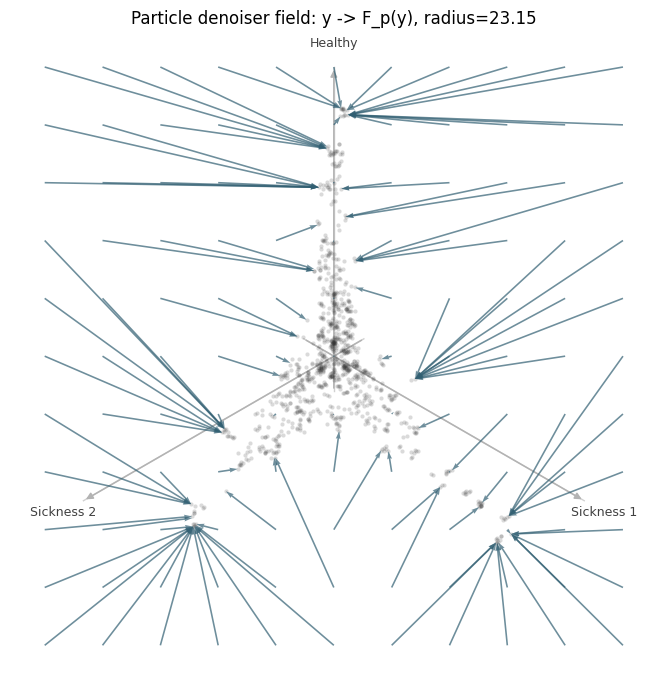

In [9]:
PLOT_DENOISER_FIELD = True
GRID_N = 11

if PLOT_DENOISER_FIELD:
    if DENOISER_FIELD_RADIUS_MODE == 'prior_quantile':
        prior_norms = np.linalg.norm(prior_xy, axis=1)
        field_radius = DENOISER_FIELD_RADIUS_MULTIPLIER * np.quantile(prior_norms, DENOISER_FIELD_PRIOR_QUANTILE)
        field_radius = max(DENOISER_FIELD_MIN_RADIUS, float(field_radius))
    elif DENOISER_FIELD_RADIUS_MODE == 'global_plot':
        field_radius = radius
    else:
        raise ValueError(f'Unknown DENOISER_FIELD_RADIUS_MODE: {DENOISER_FIELD_RADIUS_MODE}')

    xs = np.linspace(-field_radius, field_radius, GRID_N)
    ys = np.linspace(-field_radius, field_radius, GRID_N)
    grid_xy = np.array([(x, y) for y in ys for x in xs])

    # Convert display coordinates back to the minimum-norm vector in H.
    # This pseudo-inverse is only for plotting queries, not for the model state.
    frame_pinv = np.linalg.pinv(display_frame)
    grid_h = project(grid_xy @ frame_pinv)
    denoised_h = particle_denoise(grid_h, marginal_particles(state_particles))
    denoised_xy = to_display(denoised_h)
    arrows = denoised_xy - grid_xy

    fig, ax = plt.subplots(figsize=(7, 7))
    draw_state_axes(ax, field_radius)
    ax.scatter(prior_xy[:, 0], prior_xy[:, 1], s=9, color='0.20', alpha=0.18, linewidth=0)
    ax.quiver(grid_xy[:, 0], grid_xy[:, 1], arrows[:, 0], arrows[:, 1],
              angles='xy', scale_units='xy', scale=1.0, width=0.0025,
              color='#315f72', alpha=0.70)
    ax.set_title(f'Particle denoiser field: y -> F_p(y), radius={field_radius:.2f}')
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-field_radius * 1.12, field_radius * 1.12)
    ax.set_ylim(-field_radius * 1.12, field_radius * 1.12)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.tight_layout()
    plt.show()
